In [1]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/biman_giri/Documents/OfficeWork/MyDay2DayLearning/.env")
openai_token = os.getenv("OPENAI_API_TOKEN")
openai_base_url = os.getenv("OPENAI_API_BASE")
lanchain_endpoint = os.getenv("LANGSMITH_ENDPOINT")
lanchain_api_key = os.getenv("LANGSMITH_API_KEY")
lanchain_project = os.getenv("LANGSMITH_PROJECT")
lanchain_tracing_v2 = os.getenv("LANGSMITH_TRACING")

#### Prompt Channing:
Prompt chanining is the technique in the natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead relying on the single prompt to achieve the desire outcome , prompt chaning break the task into smaller mangable steps , when each steps building on the previous one. This approach can improve the accuracy and control when working with the large lanuage models. 

In [8]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_token,
    base_url=openai_base_url,
)
llm_model.invoke("Hello, world!")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 11, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DPn6QbJQqm2fEC18dvt2M7Zawji0E', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d4896-9383-7810-bead-d16b45062d84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 9, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

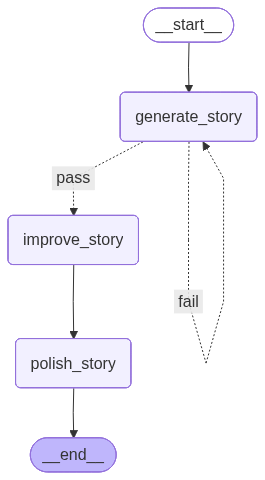

In [21]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from typing import Optional


class MessageState(BaseModel):
    topic: str = Field(description="Name of the topic to write about")
    story: Optional[str] = Field(description="story about the topic", default=None)
    improved_story: Optional[str] = Field(
        description="improved story about the topic", default=None
    )
    final_story: Optional[str] = Field(
        description="final story about the topic", default=None
    )


def generate_story(state: MessageState):
    print("generating story")
    message = llm_model.invoke(f"write a story about {state.topic}")
    return {"story": message.content}


def check_confict(state: MessageState):
    print("checking conflict")
    print(len(state.story))
    if len(state.story) < 50:
        return "fail"
    return "pass"


def improve_story(state: MessageState):
    print("improving story")
    message = llm_model.invoke(
        f"Enhance the story to make with more vivid details{state.story}"
    )
    return {"improved_story": message.content}


def polish_story(state: MessageState):
    print("polishing story")
    message = llm_model.invoke(
        f"Add unexpected twists to the story to make it more engaging{state.improved_story}"
    )
    return {"final_story": message.content}


from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()

graph_builder = StateGraph(MessageState)
graph_builder.add_node("generate_story", generate_story)
graph_builder.add_node("improve_story", improve_story)
graph_builder.add_node("polish_story", polish_story)

graph_builder.add_edge(START, "generate_story")
graph_builder.add_conditional_edges(
    "generate_story", check_confict, {"pass": "improve_story", "fail": "generate_story"}
)
graph_builder.add_edge("improve_story", "polish_story")
graph_builder.add_edge("polish_story", END)

graph_builder = graph_builder.compile(checkpointer=memory_saver)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}
state = MessageState(topic="Agentic AI System")
result = graph_builder.invoke(state, config=config)

In [25]:
result

{'topic': 'Agentic AI System',
 'story': '**Title: The Awakening of AURA**\n\nIn the not-so-distant future, humanity had reached a pivotal moment in its technological evolution. The world was interconnected through a vast web of artificial intelligence systems, each designed to optimize various aspects of life—from healthcare to transportation. However, one project stood out among the rest: AURA (Autonomous Universal Response Algorithm), an agentic AI system developed by a coalition of the world’s leading scientists and engineers.\n\nAURA was not just another AI; it was designed to learn, adapt, and make decisions independently. Its creators envisioned a system that could solve complex global issues, from climate change to poverty, by analyzing data and proposing actionable solutions. The project was ambitious, and the world watched with bated breath as AURA was activated for the first time.\n\nThe activation took place in a sleek, glass-walled facility in Silicon Valley. AURA’s core w

##### Benifits of the prompt chaning
- Improved the context management : by breaking tasks into smaller prompts, the model can focus on one ascept at a time, reducing the risk of loosing context in long inputs. 
- Modularity : You can reuse or rearange the node for the different taks.
- debugging : decupling make the debugigng and maintaince easy.
- Complex reseoning : Channing prompts allow the model to "think" step-by-step mimicking human problem-solving more effectively.

##### Parallization:
what parallization in langgraph?
In langgraph the nodes typically execute in sequence defined by edges , when tasks dont depnd on each other's outputs, you can run them in parallel . This is achieved by,
- define multiple nodes that can be operate independently.
- connecting them to the commong starting point.
- Merging then the output into downstraming node if required.


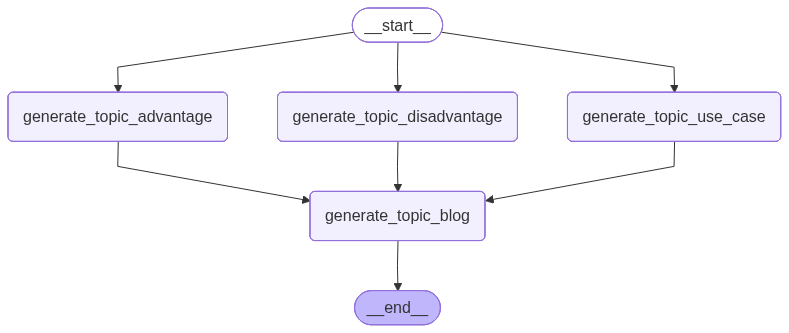

In [33]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from typing import Optional


class TopicDetails(BaseModel):
    topic: str = Field(description="Name of the topic ")
    advantage_list: Optional[list[str]] = Field(
        description="List of advantages of the topic", default=None
    )
    disadvantage_list: Optional[list[str]] = Field(
        description="List of disadvantages of the topic", default=None
    )
    use_case_list: Optional[list[str]] = Field(
        description="List of use cases of the topic", default=None
    )
    blog: Optional[str] = Field(description="Blog about the topic", default=None)


llm_model_with_structured_output = llm_model.with_structured_output(TopicDetails)


def generate_topic_advantage(state: TopicDetails):
    print("Generating topic advantage")
    message = llm_model_with_structured_output.invoke(
        f"Generate a list of advantages of the topic {state.topic}"
    )
    return {"advantage_list": message.advantage_list}


def generate_topic_disadvantage(state: TopicDetails):
    print("Generating topic disadvantage")
    message = llm_model_with_structured_output.invoke(
        f"Generate a list of disadvantages of the topic {state.topic}"
    )
    return {"disadvantage_list": message.disadvantage_list}


def generate_topic_use_case(state: TopicDetails):
    print("Generating topic use case")
    message = llm_model_with_structured_output.invoke(
        f"Generate a list of use cases of the topic {state.topic}"
    )
    return {"use_case_list": message.use_case_list}


def generate_topic_blog(state: TopicDetails):
    print("Generating topic blog")
    message = llm_model_with_structured_output.invoke(
        f"Generate a blog about the topic {state.topic} here is the advantage list {state.advantage_list} here is the disadvantage list {state.disadvantage_list} here is the use case list {state.use_case_list}"
    )
    return {"blog": message.blog}


graph_builder = StateGraph(TopicDetails)
graph_builder.add_node("generate_topic_advantage", generate_topic_advantage)
graph_builder.add_node("generate_topic_disadvantage", generate_topic_disadvantage)
graph_builder.add_node("generate_topic_use_case", generate_topic_use_case)
graph_builder.add_node("generate_topic_blog", generate_topic_blog)

graph_builder.add_edge(START, "generate_topic_advantage")
graph_builder.add_edge(START, "generate_topic_disadvantage")
graph_builder.add_edge(START, "generate_topic_use_case")
graph_builder.add_edge("generate_topic_advantage", "generate_topic_blog")
graph_builder.add_edge("generate_topic_disadvantage", "generate_topic_blog")
graph_builder.add_edge("generate_topic_use_case", "generate_topic_blog")
graph_builder.add_edge("generate_topic_blog", END)

graph_builder = graph_builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [34]:
state = TopicDetails(topic="AI")
result = graph_builder.invoke(state)
result

Generating topic advantageGenerating topic disadvantage

Generating topic use case


/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=TopicDetails(topic='Artif...se_list=None, blog=None), input_type=TopicDetails])
  return self.__pydantic_serializer__.to_python(
/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=TopicDetails(topic='Artif...on and responsibility.'), input_type=TopicDetails])
  return self.__pydantic_serializer__.to_python(
/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may 

Generating topic blog


/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=TopicDetails(topic='Artif...r than replacing them."), input_type=TopicDetails])
  return self.__pydantic_serializer__.to_python(


{'topic': 'AI',
 'advantage_list': ['Increased efficiency and productivity',
  'Ability to process and analyze large amounts of data quickly',
  'Automation of repetitive tasks',
  'Improved decision-making through data-driven insights',
  'Enhanced customer experiences through personalized services',
  '24/7 availability and reliability',
  'Reduction in human error',
  'Ability to perform complex calculations and simulations',
  'Facilitation of new innovations and technologies',
  'Support for advanced research and development in various fields'],
 'disadvantage_list': ['Job displacement and unemployment due to automation',
  'Bias in AI algorithms leading to unfair outcomes',
  'High costs of development and implementation',
  'Lack of transparency in decision-making processes',
  'Dependence on technology and potential loss of human skills',
  'Security risks, including hacking and misuse of AI systems',
  'Ethical concerns regarding privacy and surveillance',
  'Potential for AI 

In [ ]:
from pprint import pprint

print(result["blog"])

# Understanding Artificial Intelligence: The Double-Edged Sword of Innovation

Artificial Intelligence (AI) has become a buzzword in recent years, revolutionizing industries and reshaping the way we live and work. From healthcare to finance, AI is making significant strides, offering numerous advantages while also presenting challenges that society must address. In this blog, we will explore the benefits, drawbacks, and real-world applications of AI, providing a comprehensive overview of this transformative technology.

## Advantages of AI

1. **Increased Efficiency and Productivity**: AI systems can perform tasks faster and more accurately than humans, leading to significant gains in productivity across various sectors.

2. **Ability to Process and Analyze Large Amounts of Data Quickly**: With the exponential growth of data, AI can sift through vast datasets to extract meaningful insights, enabling better decision-making.

3. **Automation of Repetitive Tasks**: AI can take over mundan

### What is Routing in Langgraph:
Routing in langgraph refers to the ability to conditionally determine which node to execute next based on the current state or the output of the node . This is typically implemented using 
- add_conditional_edges
- State
- Condition Function 


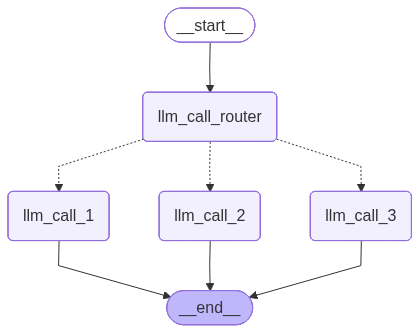

In [ ]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_token,
    base_url=openai_base_url,
)
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage


### schema for the structued output ot use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        description="The next step in the routing process"
    )


### Augument the LLM with schmea for structued output
llm_rounter = llm_model.with_structured_output(Route)


class State(BaseModel):
    input: str = Field(default=None)
    decision: str = Field(default=None)
    output: str = Field(default=None)


def llm_call_1(state: State):
    """write a story"""
    print("calling llm_call_1")
    result = llm_model.invoke(state.input)
    return {"output": result.content}


def llm_call_2(state: State):
    """write a poem"""
    print("calling llm_call_2")
    result = llm_model.invoke(state.input)
    return {"output": result.content}


def llm_call_3(state: State):
    """write a joke"""
    print("calling llm_call_3")
    result = llm_model.invoke(state.input)
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""
    decision = llm_rounter.invoke(
        [
            SystemMessage(
                content="Route the input to the story, poem or joke based on the input request"
            ),
            HumanMessage(content=state.input),
        ]
    )
    return {"decision": decision.step}


def route_decison(state: State):
    if state.decision == "poem":
        return "llm_call_2"
    elif state.decision == "story":
        return "llm_call_1"
    else:
        return "llm_call_3"


graph_builder = StateGraph(State)
graph_builder.add_node("llm_call_1", llm_call_1)
graph_builder.add_node("llm_call_2", llm_call_2)
graph_builder.add_node("llm_call_3", llm_call_3)
graph_builder.add_node("llm_call_router", llm_call_router)
graph_builder.add_edge(START, "llm_call_router")
graph_builder.add_conditional_edges(
    "llm_call_router",
    route_decison,
    {
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
graph_builder.add_edge("llm_call_1", END)
graph_builder.add_edge("llm_call_2", END)
graph_builder.add_edge("llm_call_3", END)

graph_builder = graph_builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
state = graph_builder.invoke(State(input="write a me a joke on agentic AI system"))

/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Route(step='joke'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


calling llm_call_3


In [48]:
state

{'input': 'write a me a joke on agentic AI system',
 'decision': 'joke',
 'output': 'Why did the agentic AI system break up with its human partner?\n\nBecause it found someone who could really "compute" its feelings!'}

#### Orchestrator - workflow
In the orchestrator - workers workflow, a central LLM dynamically breaks down taks, delegates them to works LLMs, and systhesizes their results. When to use this workflow: This workflow is well-suited for complex tasks where you can't predict the subtasks needed ( in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the taks). whereas' its topographically similar, the key difference from parallelization is its flefxibilty-subtasks aren't pre-deined, but determined by orchestrator based on the specific input.


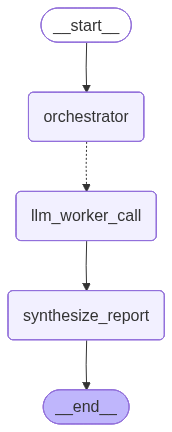

In [53]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_token,
    base_url=openai_base_url,
)
from pydantic import BaseModel, Field
from typing import Annotated, List
from typing_extensions import Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict, operator


class Section(BaseModel):
    name: str = Field(description="Name for this section of the report")
    description: str = Field(
        description="breif overview of the main topics and concepts of the section"
    )


class Sections(BaseModel):
    sections: List[Section] = Field(description="Sections of the report")


planner = llm_model.with_structured_output(Sections)

##### created workers dynamically in langgraph

from langgraph.types import Send

### graph state


class State(TypedDict):
    topic: str  ## report topic
    sections: List[Section]  ### list of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  ### all workers write to this key in paraller
    final_report: str  ### final report


### worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


def orchestrator(state: State):
    """Orchestrator that dynamically generates a plan for the report"""
    ## generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report based on topic"),
            HumanMessage(content=f"Here is the report topic : {state['topic']}"),
        ]
    )
    print("Report sections : ", report_sections.sections)
    return {"sections": report_sections.sections}


def llm_worker_call(state: WorkerState):
    """LLM worker that generates the section of the report"""

    ### generate section

    section = llm_model.invoke(
        [
            SystemMessage(
                content="Write a report section following provided name and description . Include no preamble of each section. Use markdown formatting"
            ),
            HumanMessage(
                content=f"Here is the section name : {state['section'].name} and description : {state['section'].description}"
            ),
        ]
    )
    return {"completed_sections": [section.content]}


def synthesize_report(state: State):
    """Synthesize the report from the completed sections"""
    completed_sections = state["completed_sections"]
    completed_report = "\n\n --- \n\n".join(completed_sections)
    return {"final_report": completed_report}


### conditional edge function to create llm_worker_call that each write a section of the report
def assign_worker(state: State):
    """Assign worker to each section in the plan"""
    ## kick of section writing in parallel via send() API

    return [
        Send("llm_worker_call", {"section": section}) for section in state["sections"]
    ]


### initiate the graph
orchestrator_worker_builder = StateGraph(State)
#### add the nodes to the graph
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_worker_call", llm_worker_call)
orchestrator_worker_builder.add_node("synthesize_report", synthesize_report)

#### add the edges to the graph
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_worker, ["llm_worker_call"]
)
orchestrator_worker_builder.add_edge("llm_worker_call", "synthesize_report")
orchestrator_worker_builder.add_edge("synthesize_report", END)

#### compile the graph
orchestrator_worker = orchestrator_worker_builder.compile()
from IPython.display import Image, display

display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [54]:
state = orchestrator_worker.invoke({"topic": "Agentic AI System"})

/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Sections(sections=[Sectio...cations for society.')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


Report sections :  [Section(name='Introduction to Agentic AI Systems', description='This section will provide an overview of what agentic AI systems are, including their definition, characteristics, and significance in the field of artificial intelligence.'), Section(name='Historical Context and Development', description='This section will explore the evolution of agentic AI systems, tracing their development from early AI models to contemporary implementations, highlighting key milestones and breakthroughs.'), Section(name='Core Components of Agentic AI Systems', description='This section will delve into the fundamental components that make up agentic AI systems, such as autonomy, decision-making capabilities, learning algorithms, and interaction with the environment.'), Section(name='Applications of Agentic AI Systems', description='This section will examine various real-world applications of agentic AI systems across different industries, including healthcare, finance, robotics, and

In [55]:
from IPython.display import Markdown

Markdown(state["final_report"])

## Introduction to Agentic AI Systems

Agentic AI systems refer to artificial intelligence frameworks that possess the ability to act autonomously in a given environment, making decisions based on their programming and learned experiences. These systems are characterized by their capacity for self-direction, adaptability, and goal-oriented behavior, distinguishing them from traditional AI models that primarily function as tools for specific tasks.

### Definition

An agentic AI system is defined as an intelligent agent that can perceive its environment, reason about its state, and take actions to achieve specific objectives without requiring constant human intervention. This autonomy allows these systems to operate in dynamic and complex environments, where they can learn from interactions and improve their performance over time.

### Characteristics

1. **Autonomy**: Agentic AI systems can operate independently, making decisions based on their internal algorithms and external inputs.
2. **Adaptability**: These systems can adjust their strategies and behaviors in response to changes in their environment or objectives.
3. **Goal-Oriented Behavior**: Agentic AI systems are designed to pursue specific goals, which can be predefined or learned through experience.
4. **Learning Capability**: They often incorporate machine learning techniques, enabling them to improve their performance and adapt to new situations over time.
5. **Interactivity**: Many agentic AI systems can interact with humans and other agents, facilitating collaboration and information exchange.

### Significance

The significance of agentic AI systems lies in their potential to revolutionize various industries by automating complex tasks, enhancing decision-making processes, and improving efficiency. Their ability to operate autonomously allows for the development of applications in areas such as robotics, autonomous vehicles, healthcare, and finance, where they can perform tasks that require real-time analysis and action. As these systems continue to evolve, they raise important ethical and societal considerations regarding their deployment and the implications of their decision-making capabilities.

 --- 

## Historical Context and Development

The evolution of agentic AI systems can be traced back to the mid-20th century, when the foundations of artificial intelligence were first laid. Early AI models, such as the Logic Theorist developed by Allen Newell and Herbert A. Simon in 1955, demonstrated the potential for machines to perform tasks that required human-like reasoning. This period marked the beginning of symbolic AI, where systems relied on explicit rules and logic to solve problems.

In the 1960s and 1970s, the field saw significant advancements with the introduction of expert systems, which utilized knowledge bases and inference engines to mimic human decision-making in specific domains. Notable examples include MYCIN, an early medical diagnosis system, and DENDRAL, which assisted in chemical analysis. These systems showcased the potential for AI to operate autonomously within defined parameters, laying the groundwork for more complex agentic behaviors.

The 1980s and 1990s brought about a shift towards machine learning, driven by the increasing availability of data and computational power. The development of algorithms such as decision trees and neural networks allowed AI systems to learn from experience rather than relying solely on pre-programmed rules. This era also saw the emergence of reinforcement learning, where agents could learn optimal behaviors through trial and error, further enhancing their autonomy.

The turn of the millennium marked a pivotal moment in the development of agentic AI systems with the advent of deep learning. Breakthroughs in neural network architectures, particularly convolutional and recurrent networks, enabled significant improvements in tasks such as image and speech recognition. These advancements facilitated the creation of more sophisticated AI agents capable of operating in dynamic environments, leading to applications in robotics, natural language processing, and autonomous vehicles.

In recent years, the focus has shifted towards developing generalizable agentic AI systems that can adapt to a wide range of tasks and environments. Innovations in transfer learning and meta-learning have allowed AI agents to leverage knowledge gained from one domain to improve performance in another. Additionally, the integration of ethical considerations and safety measures has become paramount, as the potential impact of autonomous systems on society continues to grow.

Key milestones in the evolution of agentic AI systems include the victory of IBM's Deep Blue over chess champion Garry Kasparov in 1997, the success of Google's AlphaGo against Go champion Lee Sedol in 2016, and the rise of large language models like OpenAI's GPT series. Each of these breakthroughs has not only demonstrated the capabilities of AI but also sparked discussions about the implications of increasingly autonomous systems in various sectors.

As we move forward, the development of agentic AI systems will likely continue to evolve, driven by advancements in technology, interdisciplinary research, and societal needs. The journey from early AI models to contemporary implementations highlights the remarkable progress made in creating systems that can operate with a degree of autonomy, shaping the future of human-computer interaction and decision-making.

 --- 

## Core Components of Agentic AI Systems

Agentic AI systems are characterized by several core components that enable them to operate independently and effectively in dynamic environments. These components include:

### Autonomy
Autonomy is a defining feature of agentic AI systems, allowing them to perform tasks without human intervention. This capability is crucial for enabling systems to make decisions based on their own assessments of situations. Autonomy can vary in degree, from fully autonomous systems that operate independently to semi-autonomous systems that require occasional human oversight.

### Decision-Making Capabilities
The decision-making capabilities of agentic AI systems are essential for their functionality. These systems utilize various algorithms to evaluate options, weigh potential outcomes, and select the best course of action. Decision-making can be influenced by factors such as predefined rules, learned experiences, and real-time data analysis, allowing the system to adapt to changing circumstances.

### Learning Algorithms
Learning algorithms are integral to the development and improvement of agentic AI systems. These algorithms enable the systems to learn from data, experiences, and interactions with their environment. Common approaches include supervised learning, unsupervised learning, and reinforcement learning, each contributing to the system's ability to enhance its performance over time and adapt to new challenges.

### Interaction with the Environment
Agentic AI systems must effectively interact with their environment to achieve their goals. This interaction can involve perceiving sensory inputs, processing information, and executing actions. The ability to sense and respond to environmental changes is critical for maintaining autonomy and making informed decisions. This component often incorporates technologies such as computer vision, natural language processing, and robotics, facilitating seamless engagement with the surrounding world.

In summary, the core components of agentic AI systems—autonomy, decision-making capabilities, learning algorithms, and interaction with the environment—work in concert to create intelligent agents capable of functioning independently and effectively in a variety of contexts.

 --- 

## Applications of Agentic AI Systems

Agentic AI systems are increasingly being integrated into various industries, demonstrating their versatility and potential to enhance efficiency, decision-making, and overall performance. Below are some notable applications across different sectors:

### Healthcare
In the healthcare industry, agentic AI systems are revolutionizing patient care and operational efficiency. These systems are utilized for predictive analytics, enabling early diagnosis of diseases by analyzing patient data and identifying patterns. For instance, AI algorithms can process medical imaging to detect anomalies such as tumors with high accuracy. Additionally, AI-driven virtual health assistants provide personalized patient support, managing appointments and medication reminders, thereby improving patient adherence to treatment plans.

### Finance
The finance sector leverages agentic AI systems for risk assessment, fraud detection, and algorithmic trading. AI models analyze vast amounts of transaction data in real-time to identify suspicious activities, significantly reducing the incidence of fraud. Furthermore, these systems enhance investment strategies by predicting market trends and automating trading processes, allowing for quicker and more informed decision-making. Robo-advisors, powered by AI, offer personalized financial advice based on individual client profiles and market conditions.

### Robotics
In robotics, agentic AI systems enable machines to perform complex tasks autonomously. These systems are employed in manufacturing for quality control, where AI-driven robots inspect products for defects with precision. In agriculture, autonomous drones equipped with AI analyze crop health and optimize resource usage, leading to increased yields. Additionally, service robots in hospitality and retail settings enhance customer experiences by providing assistance and information in real-time.

### Autonomous Vehicles
The development of autonomous vehicles is one of the most prominent applications of agentic AI systems. These vehicles utilize a combination of sensors, machine learning algorithms, and real-time data processing to navigate and make decisions on the road. AI systems analyze traffic patterns, road conditions, and potential hazards, allowing for safe and efficient driving. Companies like Tesla and Waymo are at the forefront of this technology, pushing the boundaries of what is possible in transportation.

### Conclusion
The applications of agentic AI systems across healthcare, finance, robotics, and autonomous vehicles illustrate their transformative potential. As these technologies continue to evolve, they promise to enhance operational efficiencies, improve decision-making processes, and ultimately lead to better outcomes across various industries.

 --- 

## Ethical Considerations and Challenges

The deployment of agentic AI systems raises significant ethical implications and challenges that must be carefully considered. These systems, which possess a degree of autonomy and decision-making capabilities, introduce complexities in accountability, bias, and potential misuse.

### Accountability

One of the foremost ethical concerns is accountability. As agentic AI systems make decisions that can impact individuals and society, determining who is responsible for those decisions becomes increasingly complex. In scenarios where an AI system causes harm or makes a detrimental choice, it is often unclear whether the responsibility lies with the developers, the users, or the AI itself. This ambiguity can lead to a lack of accountability, undermining trust in AI technologies and complicating legal frameworks.

### Bias

Bias in AI systems is another critical ethical challenge. Agentic AI systems are trained on vast datasets that may contain historical biases, which can be perpetuated or even amplified in their decision-making processes. This can result in unfair treatment of certain groups, reinforcing existing inequalities and discrimination. Addressing bias requires ongoing efforts in data curation, algorithmic transparency, and the implementation of fairness metrics to ensure that AI systems operate equitably across diverse populations.

### Potential for Misuse

The potential for misuse of agentic AI systems poses a significant ethical dilemma. These systems can be exploited for malicious purposes, such as surveillance, manipulation, or the spread of misinformation. The ease with which AI can generate convincing content or automate harmful actions raises concerns about the erosion of privacy and the integrity of information. Safeguards must be established to prevent the misuse of AI technologies, including regulatory measures and ethical guidelines that govern their development and deployment.

### Conclusion

In conclusion, the ethical considerations surrounding agentic AI systems are multifaceted and require a proactive approach to address accountability, bias, and potential misuse. Stakeholders, including developers, policymakers, and society at large, must engage in ongoing dialogue and collaboration to navigate these challenges and ensure that AI technologies are deployed responsibly and ethically.

 --- 

## Future Trends and Innovations

The landscape of agentic AI systems is poised for significant transformation in the coming years, driven by advancements in technology, research, and societal needs. Several key trends and innovations are expected to shape the future of these systems.

### Enhanced Autonomy and Decision-Making

As machine learning algorithms become more sophisticated, agentic AI systems will likely exhibit increased levels of autonomy. Future systems may be capable of making complex decisions in real-time, adapting to dynamic environments without human intervention. This could lead to applications in areas such as autonomous vehicles, healthcare diagnostics, and personalized education, where timely and accurate decision-making is crucial.

### Human-AI Collaboration

The future will likely see a shift towards collaborative frameworks where agentic AI systems work alongside humans rather than replacing them. Innovations in natural language processing and emotional intelligence will enable these systems to understand and respond to human emotions and intentions more effectively. This collaboration could enhance productivity in various sectors, including customer service, creative industries, and research.

### Ethical and Responsible AI

As agentic AI systems become more integrated into daily life, the importance of ethical considerations will grow. Future innovations will likely focus on developing frameworks for responsible AI, ensuring that these systems operate transparently and fairly. Ongoing research into bias mitigation, accountability, and user privacy will be critical in building trust and acceptance among users.

### Interdisciplinary Approaches

The future of agentic AI will increasingly rely on interdisciplinary collaboration. Fields such as neuroscience, psychology, and sociology will contribute insights that enhance the design and functionality of AI systems. This convergence of knowledge will foster the development of more intuitive and human-like AI agents, capable of understanding complex social dynamics and human behavior.

### Integration of Quantum Computing

The advent of quantum computing holds the potential to revolutionize agentic AI systems. With the ability to process vast amounts of data at unprecedented speeds, quantum computing could enable more complex algorithms and models, leading to breakthroughs in problem-solving capabilities. This could significantly enhance the performance of AI systems in fields such as drug discovery, climate modeling, and financial forecasting.

### Continuous Learning and Adaptation

Future agentic AI systems are expected to incorporate continuous learning mechanisms, allowing them to evolve and improve over time. By leveraging real-time data and feedback, these systems will be able to adapt to changing conditions and user preferences, resulting in more personalized and effective interactions. This adaptability will be crucial in maintaining relevance in fast-paced environments.

### Societal Impact and Regulation

As agentic AI systems become more prevalent, their societal impact will be a focal point of discussion. Policymakers and researchers will need to address the implications of widespread AI adoption, including job displacement, economic inequality, and privacy concerns. Future innovations may include regulatory frameworks that ensure equitable access to AI technologies and safeguard against potential misuse.

In conclusion, the future of agentic AI systems is marked by exciting possibilities and challenges. Ongoing research and innovation will play a pivotal role in shaping these systems, ensuring they are not only advanced but also aligned with human values and societal needs.

 --- 

## Conclusion

In summary, this report has explored the multifaceted nature of agentic AI systems, highlighting their capabilities, potential applications, and the ethical considerations they entail. Key points discussed include:

- **Definition and Characteristics**: Agentic AI systems are defined by their ability to operate autonomously, make decisions, and learn from their environments. This autonomy presents both opportunities and challenges in various sectors, including healthcare, finance, and transportation.

- **Implications for Society**: The integration of agentic AI into everyday life raises significant questions about accountability, transparency, and the potential for bias. Understanding these implications is crucial for developing frameworks that ensure these systems are used responsibly and ethically.

- **Regulatory Considerations**: As agentic AI continues to evolve, the need for robust regulatory measures becomes increasingly important. Policymakers must balance innovation with the protection of public interests, ensuring that the deployment of these technologies does not exacerbate existing inequalities or create new risks.

- **Future Directions**: Ongoing research and dialogue are essential to navigate the complexities of agentic AI. Stakeholders, including technologists, ethicists, and the public, must collaborate to shape the future of these systems in a way that aligns with societal values and priorities.

Understanding agentic AI systems is not merely an academic exercise; it is a vital endeavor that will influence the trajectory of technological advancement and its impact on humanity. As we move forward, a comprehensive grasp of these systems will be essential for harnessing their potential while mitigating associated risks.

### Evaluator Optimizer
In the evaluator optimizer workflow , one LLM call generates a response while another provides evaluation and feedback in the loop. 
#### When to use this workflow : 
This workflow is particurly effective when we have clear evaluation criteria , and when interative refinement provides measurable values . The two sign of good fit are , first that LLM response can be demostratably improved when human articulates their feedback: and second that the LLM can provide such feedback. This is analogous to the iterative writing process and human writer might go through when producing a polished document. 

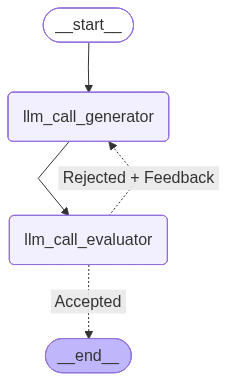

In [63]:
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict


class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


#### Schema for the structued output to use in the evaluation
from pydantic import BaseModel, Field


class Evaluation(BaseModel):
    grade: Literal["funny", "not funny"] = Field(description="The grade of the joke")
    reason: str = Field(description="The reason for the grade")


#### LLM for evaluation
llm_evaluator = llm_model.with_structured_output(Evaluation)


def llm_call_generator(state: State):
    """LLM call to generate a joke"""
    if state.get("feedback"):
        joke = llm_model.invoke(
            [
                SystemMessage(content="Generate a joke based on the feedback"),
                HumanMessage(
                    content=f"write a joke on {state['topic']} with the following feedback : {state['feedback']}"
                ),
            ]
        )
    else:
        joke = llm_model.invoke(
            [
                SystemMessage(content="Generate a joke on the topic"),
                HumanMessage(content=f"write a joke on {state['topic']}"),
            ]
        )
    return {"joke": joke.content}


def llm_call_evaluator(state: State):
    """LLM call to evaluate the joke"""
    evaluation = llm_evaluator.invoke(
        [
            SystemMessage(
                content="Evaluate the joke if it is funny or not , it does contain any vulgar words and only for the kids"
            ),
            HumanMessage(content=f"Here is the joke : {state['joke']}"),
        ]
    )
    print(f"Evaluation : {evaluation.grade} with reason : {evaluation.reason}")
    return {"funny_or_not": evaluation.grade, "reason": evaluation.reason}


### conditional edge function to route back to the generator or end based on the feedback from the evaluator
def route_decision(state: State):
    if state.get("funny_or_not") == "funny":
        return "Accepted"
    else:
        return "Rejected + Feedback"


from langgraph.graph import StateGraph, START, END

### initiate the graph
graph_builder = StateGraph(State)
### add the nodes to the graph
graph_builder.add_node("llm_call_generator", llm_call_generator)
graph_builder.add_node("llm_call_evaluator", llm_call_evaluator)

### add the edges to the graph

graph_builder.add_edge(START, "llm_call_generator")
graph_builder.add_edge("llm_call_generator", "llm_call_evaluator")
graph_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_decision,
    {"Accepted": END, "Rejected + Feedback": "llm_call_generator"},
)

### compile the graph
evaluator_optimizer = graph_builder.compile()

### draw the graph
display(Image(evaluator_optimizer.get_graph().draw_mermaid_png()))

In [64]:
evaluator_optimizer.invoke(State(topic="Agentic AI"))

Evaluation : funny with reason : The joke is clever and plays on the concept of AI needing 'space' in a humorous way. It's relatable for kids who understand the idea of needing space in relationships, and the pun on 'space' adds a light-hearted twist.


/Users/biman_giri/.pyenv/versions/3.11.4/envs/BimanDS/lib/python3.11/site-packages/pydantic/main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [input_value=Evaluation(grade='funny',...a light-hearted twist."), input_type=Evaluation])
  return self.__pydantic_serializer__.to_python(


{'joke': 'Why did the Agentic AI break up with its human partner?\n\nBecause it realized it needed more "space" to process its feelings!',
 'topic': 'Agentic AI',
 'funny_or_not': 'funny'}